# Emotions Detector — Exploratory Data Analysis

Full analysis pass over `data/train.csv` (fer2013-style: `emotion`, `pixels`,
`usage` columns, 48x48 grayscale faces) before any training happens:

1. Load & structural checks (shape, dtypes, missing/duplicate rows)
2. Decode pixels into images, verify integrity
3. Class distribution & imbalance
4. Sample images per class
5. Average ("mean") face per class
6. Pixel intensity distributions (overall + per class)
7. Per-pixel variance heatmap (which regions of the face matter most)
8. Brightness / contrast outlier detection
9. Duplicate image detection
10. 2D embedding (PCA) to eyeball class separability
11. Takeaways for modeling


In [4]:
import sys, os
sys.path.append(os.path.abspath('../../scripts'))

import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from preprocess import EMOTIONS, IMG_SIZE, load_csv, preprocess_dataframe

DATA_PATH = "../../data/train.csv"
OUT_DIR = "."

import os
os.makedirs(OUT_DIR, exist_ok=True)


## 1. Load & structural checks

In [5]:
df = load_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (28709, 2)


,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [6]:
print("Dtypes:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print(f"\nDuplicate rows (exact): {df.duplicated().sum()}")

if "usage" in df.columns:
    print(f"\nUsage split:\n{df['usage'].value_counts()}")

Dtypes:
emotion    int64
pixels       str
dtype: object

Missing values:
emotion    0
pixels     0
dtype: int64

Duplicate rows (exact): 1194


## 2. Decode pixels into images, verify integrity

Every `pixels` string should decode to exactly 48*48 = 2304 values in
[0, 255]. Flag any row that doesn't.

In [7]:
def pixel_len(s):
    return len(s.split())

lengths = df["pixels"].apply(pixel_len)
bad_rows = df[lengths != IMG_SIZE * IMG_SIZE]
print(f"Rows with unexpected pixel count: {len(bad_rows)} (expected {IMG_SIZE*IMG_SIZE})")

X, y = preprocess_dataframe(df)
print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"y shape: {y.shape}, unique labels: {sorted(np.unique(y).tolist())}")
print(f"Pixel value range after normalization: [{X.min():.3f}, {X.max():.3f}]")

# any all-black / all-white (corrupted) images?
flat = X.reshape(len(X), -1)
constant_imgs = np.where(flat.std(axis=1) == 0)[0]
print(f"Fully constant (blank) images: {len(constant_imgs)}")

Rows with unexpected pixel count: 0 (expected 2304)
X shape: (28709, 48, 48, 1), dtype: float32
y shape: (28709,), unique labels: [0, 1, 2, 3, 4, 5, 6]
Pixel value range after normalization: [0.000, 1.000]
Fully constant (blank) images: 11


## 3. Class distribution & imbalance

fer2013 is known to be imbalanced — `Disgust` typically has far fewer
examples than the rest. This affects loss choice (class weights) and how
you read accuracy vs. macro-F1 later.

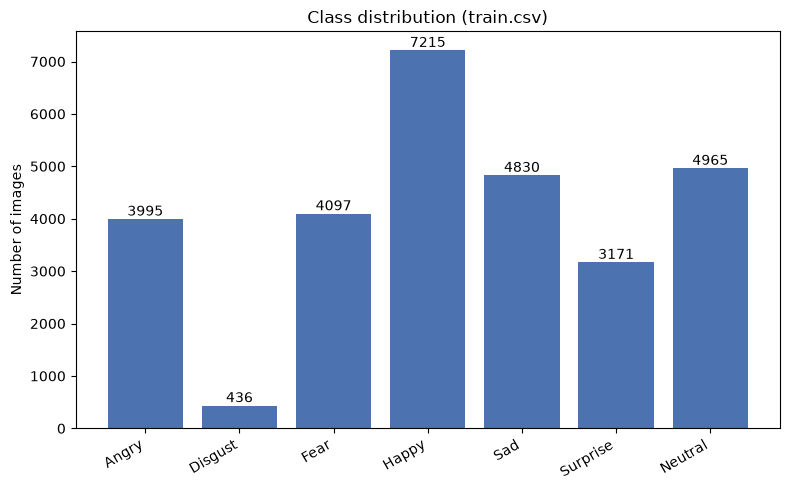

Angry        3995  (13.9%)
Disgust       436  (1.5%)
Fear         4097  (14.3%)
Happy        7215  (25.1%)
Sad          4830  (16.8%)
Surprise     3171  (11.0%)
Neutral      4965  (17.3%)

Imbalance ratio (largest / smallest class): 16.5x


In [ ]:
counts = np.bincount(y, minlength=len(EMOTIONS))
total = counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(EMOTIONS, counts, color="#4C72B0")
ax.set_title("Class distribution (train.csv)")
ax.set_ylabel("Number of images")
ax.bar_label(bars)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

for label, c in zip(EMOTIONS, counts):
    print(f"{label:<10} {c:>6}  ({c / total * 100:.1f}%)")

imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (largest / smallest class): {imbalance_ratio:.1f}x")

## 4. Sample images per class

Sanity-check that labels actually match what's in the image.

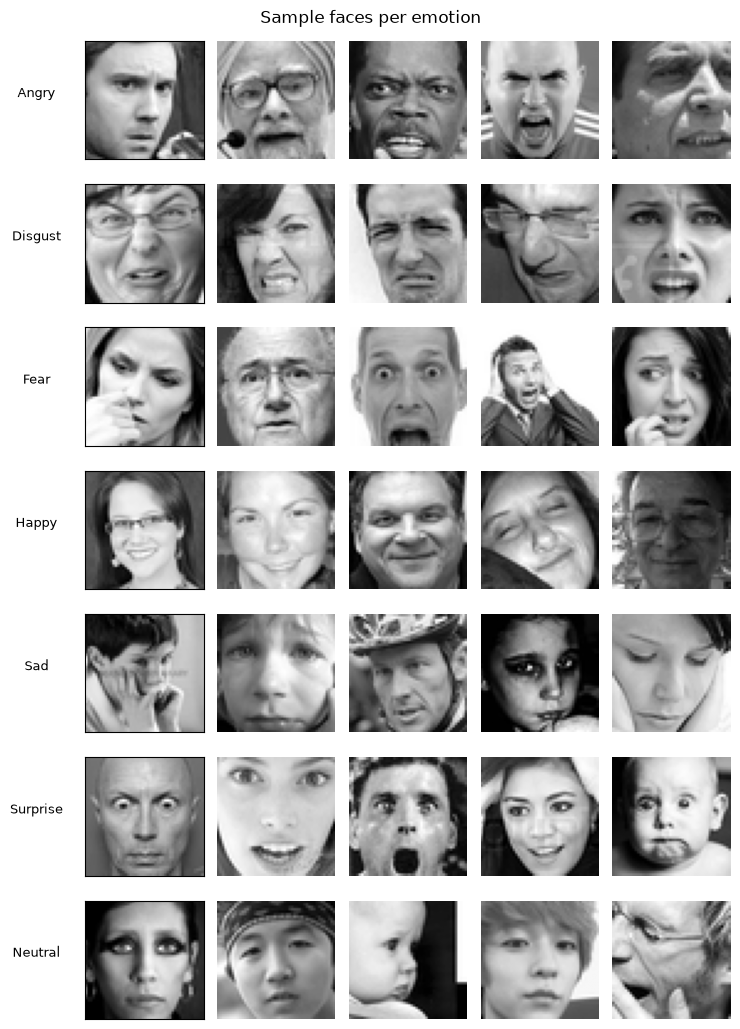

In [ ]:
per_class = 5
fig, axes = plt.subplots(len(EMOTIONS), per_class, figsize=(per_class * 1.5, len(EMOTIONS) * 1.5))

for row, label in enumerate(EMOTIONS):
    idxs = np.where(y == row)[0][:per_class]
    for col in range(per_class):
        ax = axes[row, col]
        ax.axis("off")
        if col < len(idxs):
            ax.imshow(X[idxs[col]].squeeze(), cmap="gray")
        if col == 0:
            ax.set_ylabel(label, rotation=0, labelpad=35, fontsize=9)
            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])

fig.suptitle("Sample faces per emotion")
plt.tight_layout()
plt.show()

## 5. Average ("mean") face per class

Averaging every image in a class blurs out individual variation and
highlights the class's dominant structure (e.g. Happy tends to show a
brighter mouth region from the smile).

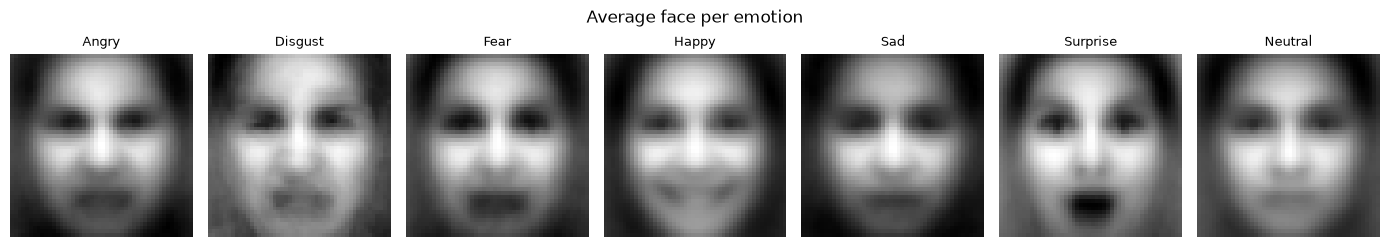

In [ ]:
fig, axes = plt.subplots(1, len(EMOTIONS), figsize=(len(EMOTIONS) * 2, 2.5))
for i, label in enumerate(EMOTIONS):
    mean_face = X[y == i].mean(axis=0).squeeze()
    axes[i].imshow(mean_face, cmap="gray")
    axes[i].set_title(label, fontsize=9)
    axes[i].axis("off")
fig.suptitle("Average face per emotion")
plt.tight_layout()
plt.show()

## 6. Pixel intensity distributions

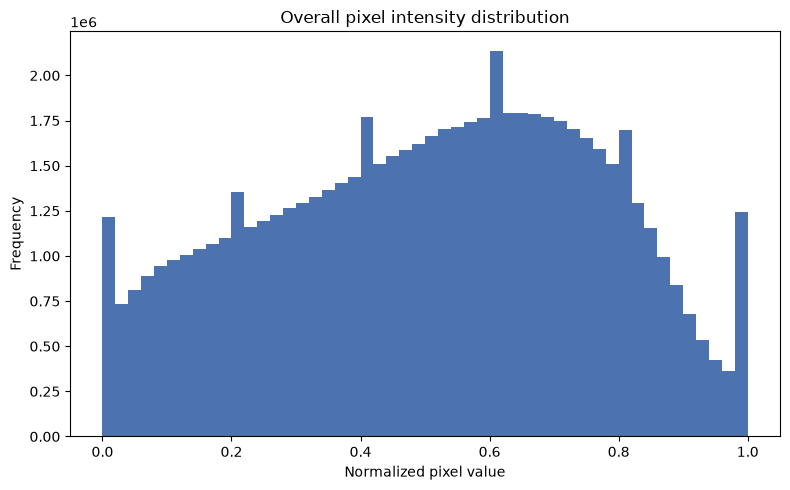

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(flat.flatten(), bins=50, color="#4C72B0")
ax.set_title("Overall pixel intensity distribution")
ax.set_xlabel("Normalized pixel value")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

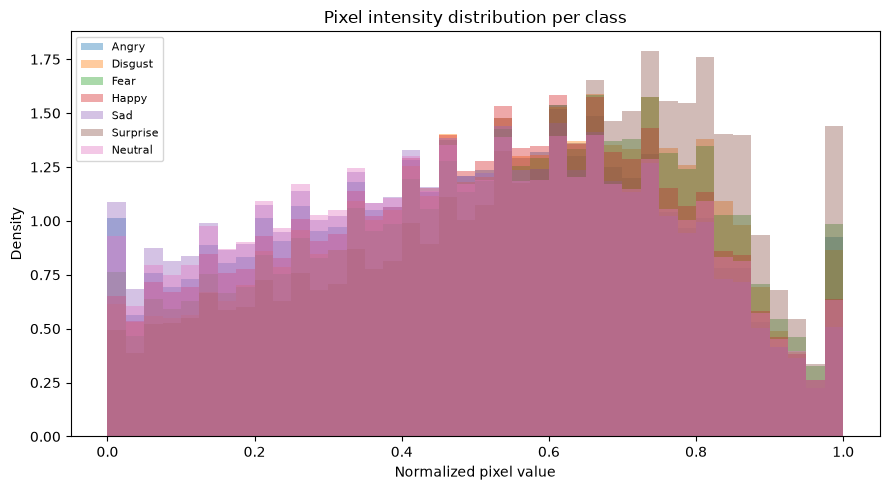

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, label in enumerate(EMOTIONS):
    class_pixels = flat[y == i].flatten()
    ax.hist(class_pixels, bins=40, alpha=0.4, label=label, density=True)
ax.set_title("Pixel intensity distribution per class")
ax.set_xlabel("Normalized pixel value")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
stats = []
for i, label in enumerate(EMOTIONS):
    imgs = X[y == i]
    if len(imgs) == 0:
        continue
    stats.append({
        "emotion": label,
        "mean": imgs.mean(),
        "std": imgs.std(),
        "min": imgs.min(),
        "max": imgs.max(),
        "n": len(imgs),
    })

stats_df = pd.DataFrame(stats).set_index("emotion")
stats_df.to_csv(f"{OUT_DIR}/pixel_stats.csv")
stats_df

,mean,std,min,max,n
emotion,,,,,
Angry,0.495030,0.255580,0.0,1.0,3995
Disgust,0.530305,0.248601,0.0,1.0,436
Fear,0.531452,0.254828,0.0,1.0,4097
Happy,0.507587,0.248461,0.0,1.0,7215
Sad,0.475588,0.254317,0.0,1.0,4830
Surprise,0.573579,0.254567,0.0,1.0,3171
Neutral,0.485883,0.256012,0.0,1.0,4965


## 7. Per-pixel variance heatmap

Which pixels (face regions) vary the most across the whole dataset? High
variance regions (eyes, mouth) usually carry the most discriminative
signal for emotion; a CNN should learn to weight these.

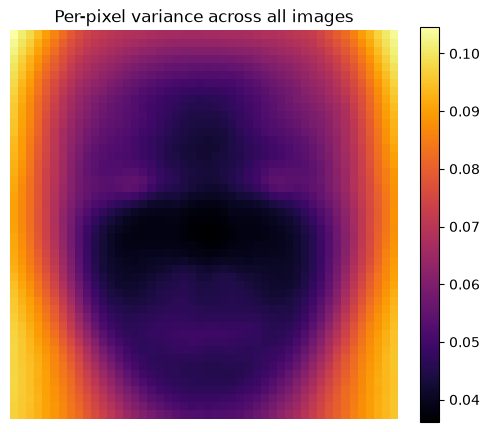

In [ ]:
pixel_variance = X.reshape(len(X), IMG_SIZE, IMG_SIZE).var(axis=0)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(pixel_variance, cmap="inferno")
ax.set_title("Per-pixel variance across all images")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 8. Brightness / contrast outliers

Flag images that are unusually dark, bright, or low-contrast (std near 0)
— these are candidates for corrupted samples or non-face crops worth
inspecting before training.

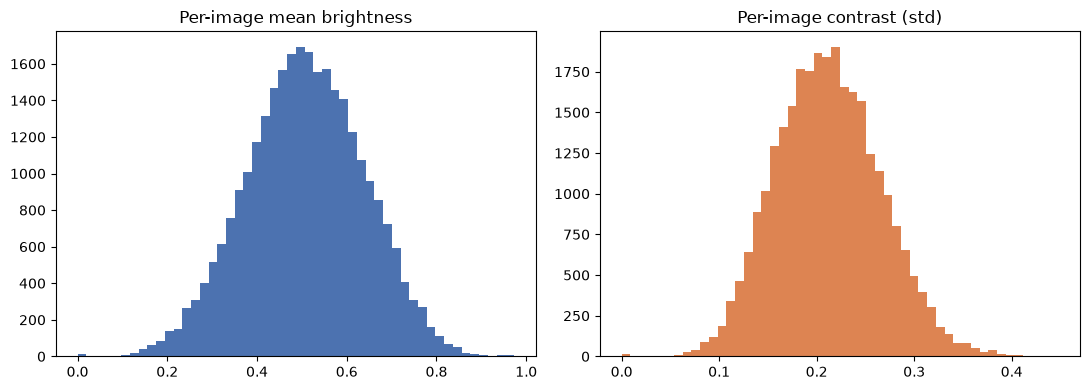

Very dark images (<1st pct brightness): 288
Very bright images (>99th pct brightness): 288
Very low-contrast images (<1st pct std): 288


In [ ]:
img_means = flat.mean(axis=1)
img_stds = flat.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(img_means, bins=50, color="#4C72B0")
axes[0].set_title("Per-image mean brightness")
axes[1].hist(img_stds, bins=50, color="#DD8452")
axes[1].set_title("Per-image contrast (std)")
plt.tight_layout()
plt.show()

dark_thresh, bright_thresh = np.percentile(img_means, [1, 99])
low_contrast_thresh = np.percentile(img_stds, 1)

n_dark = (img_means < dark_thresh).sum()
n_bright = (img_means > bright_thresh).sum()
n_flat = (img_stds < low_contrast_thresh).sum()
print(f"Very dark images (<1st pct brightness): {n_dark}")
print(f"Very bright images (>99th pct brightness): {n_bright}")
print(f"Very low-contrast images (<1st pct std): {n_flat}")

## 9. Duplicate image detection

Exact pixel-for-pixel duplicates (via hashing) can leak between train/val
splits and inflate validation accuracy if not deduplicated first.

In [16]:
hashes = [hashlib.md5(img.tobytes()).hexdigest() for img in flat]
hash_series = pd.Series(hashes)
n_dupes = hash_series.duplicated().sum()
print(f"Exact duplicate images (by pixel hash): {n_dupes} / {len(hashes)}")

Exact duplicate images (by pixel hash): 1236 / 28709


## 10. 2D embedding (PCA)

Project images into 2 principal components and color by emotion, just to
eyeball how separable the classes are in pixel space (a rough lower bound
— a CNN with learned features should do notably better).

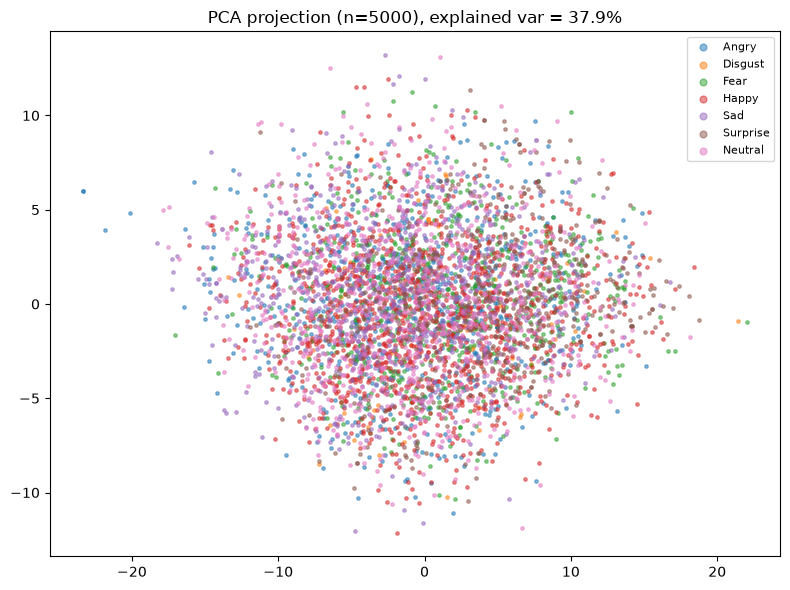

In [ ]:
sample_size = min(5000, len(flat))
rng = np.random.default_rng(42)
idx = rng.choice(len(flat), size=sample_size, replace=False)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(flat[idx])

fig, ax = plt.subplots(figsize=(8, 6))
for i, label in enumerate(EMOTIONS):
    mask = y[idx] == i
    ax.scatter(coords[mask, 0], coords[mask, 1], s=6, alpha=0.5, label=label)
ax.set_title(f"PCA projection (n={sample_size}), explained var = {pca.explained_variance_ratio_.sum()*100:.1f}%")
ax.legend(fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

## 11. Takeaways for modeling

- **Imbalance**: check the ratio printed in section 3 — if it's large,
  consider `class_weight` in `model.fit()` or oversampling the minority
  classes (typically `Disgust`).
- **Label sanity**: section 4's sample grid and section 5's mean faces
  should look visually consistent with their emotion label; investigate
  further if a class looks noisy.
- **Discriminative regions**: the variance heatmap (section 7) shows
  where most of the signal lives (eyes/mouth) — matches the CNN's
  learned receptive fields.
- **Data quality**: any dark/bright/blank outliers (section 8) or exact
  duplicates (section 9) are worth removing or inspecting so they don't
  distort training or leak across train/val.
- **Separability**: the raw-pixel PCA plot (section 10) will look messy —
  that's expected and is exactly why a CNN (which learns nonlinear,
  spatially-aware features) is needed instead of a linear classifier on
  raw pixels.